# Readout Charge-Gate Power with Reference — Analyzer Development
Prototype a new analyzer step by step.  
Load a pre-parsed `xarray.Dataset` from an `.h5` file and explore the raw data.

In [72]:

import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data
import numpy as np
import os


## 1. Configuration

In [73]:

# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\two_step_AR\ro_charge_power_post_selected.h5"

# Optional: paths for saving outputs (set to None to skip saving)
METADATA_SAVE_PATH = None   # e.g. r"output/state_disc_results.pkl"
FIGURE_SAVE_PATH   = os.path.join(os.path.dirname(H5_PATH), "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)
# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "user_mean": [[0.1, 0.2], [0.3, 0.4]],  # initial guess for GMM centers
    # "user_std": 0.05,                         # initial guess for Gaussian std
    "outlier_sigma": 3,                       # outlier detection threshold
}
photon_convert_factor = 500  # Adjust this factor based on your system's calibration

## 2. Load Dataset

In [74]:
sq_data = load_xarray_h5(H5_PATH)
sq_data

<xarray.Dataset> Size: 111MB
Dimensions:              (prepared_state: 2, charge_gate: 49,
                          amp_prefactor: 20, shot_idx: 1160)
Coordinates:
  * charge_gate          (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.47 0.48
  * amp_prefactor        (amp_prefactor) float64 160B 0.0 0.1 0.2 ... 1.8 1.9
  * prepared_state       (prepared_state) int32 8B 0 1
    qubit                object 8B 'q1'
  * shot_idx             (shot_idx) int64 9kB 0 1 2 3 4 ... 1156 1157 1158 1159
Data variables:
    I1_1                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 18MB ...
    I1_2                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 18MB ...
    I1_3                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 18MB ...
    Q1_1                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 18MB ...
    Q1_2                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 18MB ...
    Q1_3                 (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 18MB ...
    post_selection_mask  (prepared_state, charge_gate, amp_prefactor, shot_idx) bool 2MB ...
Attributes:
    abscos_frequency_fixed:  0.54
    mean:                    [-0.00232174 -0.00128172]
    std:                     0.0005580312306081581

## 3. Explore Dataset Structure
Inspect dimensions, coordinates, variables, and attributes.

In [75]:

print("=== Dimensions ===")
print(sq_data.dims)
print("\n=== Coordinates ===")
for name, coord in sq_data.coords.items():
    print(f"  {name}: shape={coord.shape}, dtype={coord.dtype}, values={coord.values if coord.size < 20 else f'[{coord.values[0]} ... {coord.values[-1]}] (len={coord.size})'}")
print("\n=== Data Variables ===")
for name, var in sq_data.data_vars.items():
    print(f"  {name}: shape={var.shape}, dims={var.dims}, dtype={var.dtype}")
print("\n=== Attributes ===")
for k, v in sq_data.attrs.items():
    print(f"  {k}: {v}")

=== Dimensions ===
FrozenMappingWarningOnValuesAccess({'prepared_state': 2, 'charge_gate': 49, 'amp_prefactor': 20, 'shot_idx': 1160})

=== Coordinates ===
  charge_gate: shape=(49,), dtype=float64, values=[0.0 ... 0.48] (len=49)
  amp_prefactor: shape=(20,), dtype=float64, values=[0.0 ... 1.9] (len=20)
  prepared_state: shape=(2,), dtype=int32, values=[0 1]
  qubit: shape=(), dtype=object, values=q1
  shot_idx: shape=(1160,), dtype=int64, values=[0 ... 1159] (len=1160)

=== Data Variables ===
  I1_1: shape=(2, 49, 20, 1160), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_2: shape=(2, 49, 20, 1160), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_3: shape=(2, 49, 20, 1160), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_1: shape=(2, 49, 20, 1160), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_2: shape=(2, 49, 20, 1160), dims

In [76]:
# Check if post_selection_mask exists in the dataset
print("Looking for post_selection_mask in dataset...")
if 'post_selection_mask' in sq_data.data_vars:
    print("Found post_selection_mask!")
    print(f"post_selection_mask shape: {sq_data['post_selection_mask'].shape}")
    print(f"post_selection_mask dims: {sq_data['post_selection_mask'].dims}")
    print(f"Number of post-selected: {sq_data['post_selection_mask'].sum().values}")
    print(f"Percentage post-selected: {100 * sq_data['post_selection_mask'].mean().values:.2f}%")
else:
    print("No post_selection_mask found in dataset.")
    print("Available data variables:")
    for var_name in sq_data.data_vars:
        print(f"  - {var_name}")


Looking for post_selection_mask in dataset...
Found post_selection_mask!
post_selection_mask shape: (2, 49, 20, 1160)
post_selection_mask dims: ('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx')
Number of post-selected: 194269
Percentage post-selected: 8.54%


In [77]:
from scqat.protocols.single_state_outlier import SingleStateOutlierAnalyzer

# Stack all dims except prepared_state into a flat shot_idx, one dataset per prepared_state
# Pre-filter by existing post_selection_mask (drop shots where mask is True)
dims_to_stack = [d for d in sq_data['I1_3'].dims if d != 'prepared_state']
outlier_datasets = {}
for state in sq_data.coords['prepared_state'].values:
    subset = sq_data[['I1_3', 'Q1_3', 'post_selection_mask']].sel(prepared_state=state)
    mask_flat = subset['post_selection_mask'].values.ravel()
    I_flat = subset['I1_3'].values.ravel()[~mask_flat]
    Q_flat = subset['Q1_3'].values.ravel()[~mask_flat]
    ds = xr.Dataset(
        {'I': ('shot_idx', I_flat), 'Q': ('shot_idx', Q_flat)},
        coords={'shot_idx': np.arange(len(I_flat))},
    )
    outlier_datasets[int(state)] = ds
    print(f"prepared_state={state}: {len(I_flat)} shots (dropped {mask_flat.sum()} post-selected)")

# Run SingleStateOutlierAnalyzer on each prepared_state
analyzer = SingleStateOutlierAnalyzer()
outlier_results = {}
for state, ds in outlier_datasets.items():
    print(f"--- Analyzing prepared_state={state} ---")
    result = analyzer.analyze(ds, **ANALYSIS_KWARGS)
    outlier_results[state] = result


prepared_state=0: 1079937 shots (dropped 56863 post-selected)
prepared_state=1: 999394 shots (dropped 137406 post-selected)
--- Analyzing prepared_state=0 ---
--- Analyzing prepared_state=1 ---


Prepared state: 0
fitted_paras: {'mean': array([[-0.00232973, -0.00126953]]), 'sigma_x': 0.0005622811627481461, 'sigma_y': 0.0005622811627481461, 'std': 0.0005622811627481461, 'amp': 473966.31754050136, 'offset': 0.0}


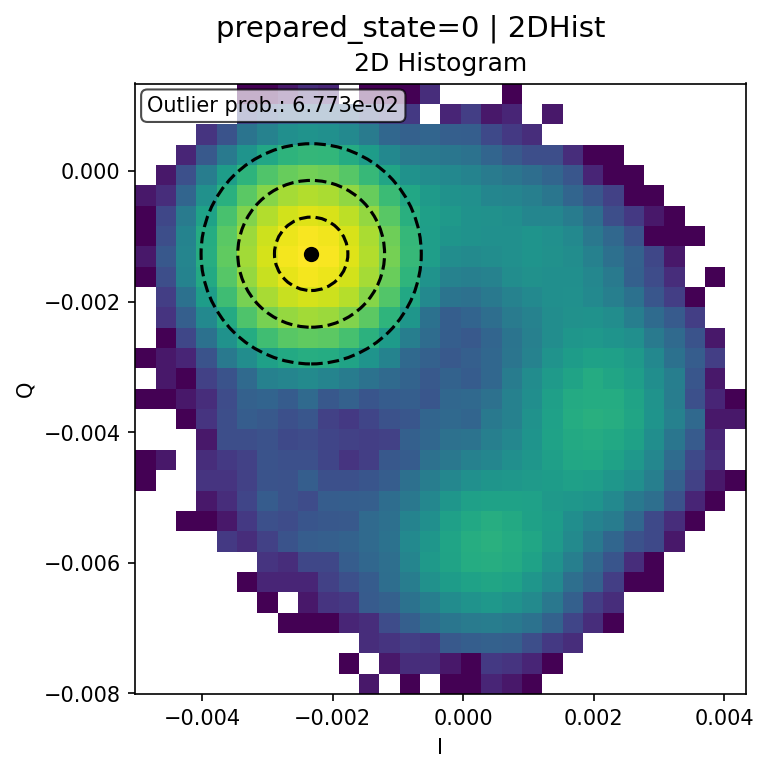

Prepared state: 1
fitted_paras: {'mean': array([[ 0.00121485, -0.0012875 ]]), 'sigma_x': 0.0005747686718469147, 'sigma_y': 0.0005747686718469147, 'std': 0.0005747686718469147, 'amp': 350686.0686148869, 'offset': 0.0}


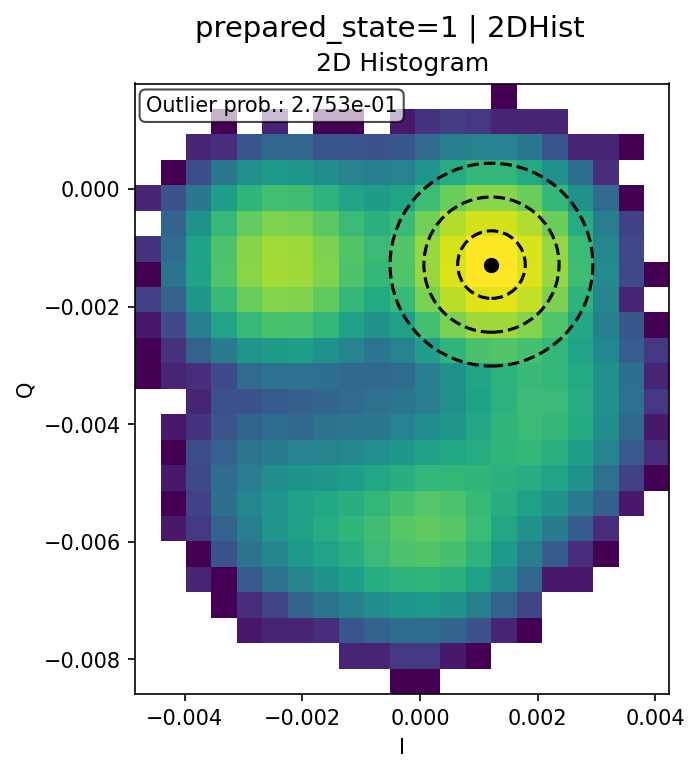

In [78]:
# Display figures from SingleStateOutlierAnalyzer results
for state, (params, figs) in outlier_results.items():
    print(f"Prepared state: {state}")
    print(f"fitted_paras: {params['fitted_paras']}")
    for fig_name, fig in figs.items():
        fig.suptitle(f"prepared_state={state} | {fig_name}", fontsize=14, y=1.02)
        display(fig)
        plt.close(fig)

In [79]:
outlier_sigma = ANALYSIS_KWARGS.get('outlier_sigma', 3)
charge_vals = sq_data.coords['charge_gate'].values
amp_vals = sq_data.coords['amp_prefactor'].values
prepared_states = sq_data.coords['prepared_state'].values
grid_shape = (len(prepared_states), len(amp_vals), len(charge_vals))
grid_dims = ['prepared_state', 'amp_prefactor', 'charge_gate']
grid_coords = {'prepared_state': prepared_states, 'amp_prefactor': amp_vals, 'charge_gate': charge_vals}

# Initialize result arrays for set_3 and set_2
results_3 = {k: np.full(grid_shape, np.nan) for k in ['outlier_probability', 'I_mean', 'Q_mean', 'std']}
results_2 = {k: np.full(grid_shape, np.nan) for k in ['outlier_probability', 'I_mean', 'Q_mean', 'std']}

# Per-grid-point outlier detection for set_3 (fixed fit from global parameters)
not_maps_3 = {}
for si, state in enumerate(prepared_states):
    params_global, _ = outlier_results[int(state)]
    fixed_mean = params_global['fitted_paras']['mean'][0]
    fixed_std = params_global['fitted_paras']['std']

    subset = sq_data[['I1_3', 'Q1_3', 'post_selection_mask']].sel(prepared_state=state)

    for ci, cg in enumerate(charge_vals):
        for ai, ap in enumerate(amp_vals):
            cell = subset.sel(charge_gate=cg, amp_prefactor=ap)
            mask = cell['post_selection_mask'].values.ravel()
            valid_idx = ~mask
            if valid_idx.sum() == 0:
                continue
            I_valid = cell['I1_3'].values.ravel()[valid_idx]
            Q_valid = cell['Q1_3'].values.ravel()[valid_idx]
            ds = xr.Dataset(
                {'I': ('shot_idx', I_valid), 'Q': ('shot_idx', Q_valid)},
                coords={'shot_idx': np.arange(len(I_valid))},
            )
            result, _ = analyzer.analyze(
                ds, skip_figures=True,
                fixed_mean=fixed_mean, fixed_std=fixed_std,
                outlier_sigma=outlier_sigma,
            )
            results_3['outlier_probability'][si, ai, ci] = result['outlier_probability']
            results_3['I_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][0]
            results_3['Q_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][1]
            results_3['std'][si, ai, ci] = result['fitted_paras']['std']

    label = f"not_{int(state)}"
    not_maps_3[label] = xr.DataArray(
        results_3['outlier_probability'][si], dims=['amp_prefactor', 'charge_gate'],
        coords={'amp_prefactor': amp_vals, 'charge_gate': charge_vals},
    )

# Per-grid-point outlier detection for set_2 (free fit per grid cell)
not_maps_2 = {}
for si, state in enumerate(prepared_states):
    subset = sq_data[['I1_2', 'Q1_2', 'post_selection_mask']].sel(prepared_state=state)

    for ci, cg in enumerate(charge_vals):
        for ai, ap in enumerate(amp_vals):
            cell = subset.sel(charge_gate=cg, amp_prefactor=ap)
            mask = cell['post_selection_mask'].values.ravel()
            valid_idx = ~mask
            if valid_idx.sum() < 10:
                continue
            I_valid = cell['I1_2'].values.ravel()[valid_idx]
            Q_valid = cell['Q1_2'].values.ravel()[valid_idx]
            ds = xr.Dataset(
                {'I': ('shot_idx', I_valid), 'Q': ('shot_idx', Q_valid)},
                coords={'shot_idx': np.arange(len(I_valid))},
            )
            try:
                result, _ = analyzer.analyze(
                    ds, skip_figures=True,
                    outlier_sigma=outlier_sigma,
                )
                results_2['outlier_probability'][si, ai, ci] = result['outlier_probability']
                results_2['I_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][0]
                results_2['Q_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][1]
                results_2['std'][si, ai, ci] = result['fitted_paras']['std']
            except Exception as e:
                print(f"  Fit failed at cg={cg}, ap={ap}, state={state}: {e}")
                continue

    label = f"not_{int(state)}"
    not_maps_2[label] = xr.DataArray(
        results_2['outlier_probability'][si], dims=['amp_prefactor', 'charge_gate'],
        coords={'amp_prefactor': amp_vals, 'charge_gate': charge_vals},
    )

# Assemble result dataset
result_ds = xr.Dataset(
    {f"{var}_set{s}": (grid_dims, data)
     for s, res in [('3', results_3), ('2', results_2)]
     for var, data in res.items()},
    coords=grid_coords,
    attrs=sq_data.attrs,
)
result_ds.attrs['outlier_sigma'] = outlier_sigma
print(result_ds)


<xarray.Dataset> Size: 126kB
Dimensions:                   (prepared_state: 2, amp_prefactor: 20,
                               charge_gate: 49)
Coordinates:
  * prepared_state            (prepared_state) int32 8B 0 1
  * amp_prefactor             (amp_prefactor) float64 160B 0.0 0.1 ... 1.8 1.9
  * charge_gate               (charge_gate) float64 392B 0.0 0.01 ... 0.47 0.48
Data variables:
    outlier_probability_set3  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    I_mean_set3               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    Q_mean_set3               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    std_set3                  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    outlier_probability_set2  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    I_mean_set2               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    Q_mean_set2               (prepared_state, amp_pre

Saved to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\two_step_AR\figures\outlier_fraction_state_0.png


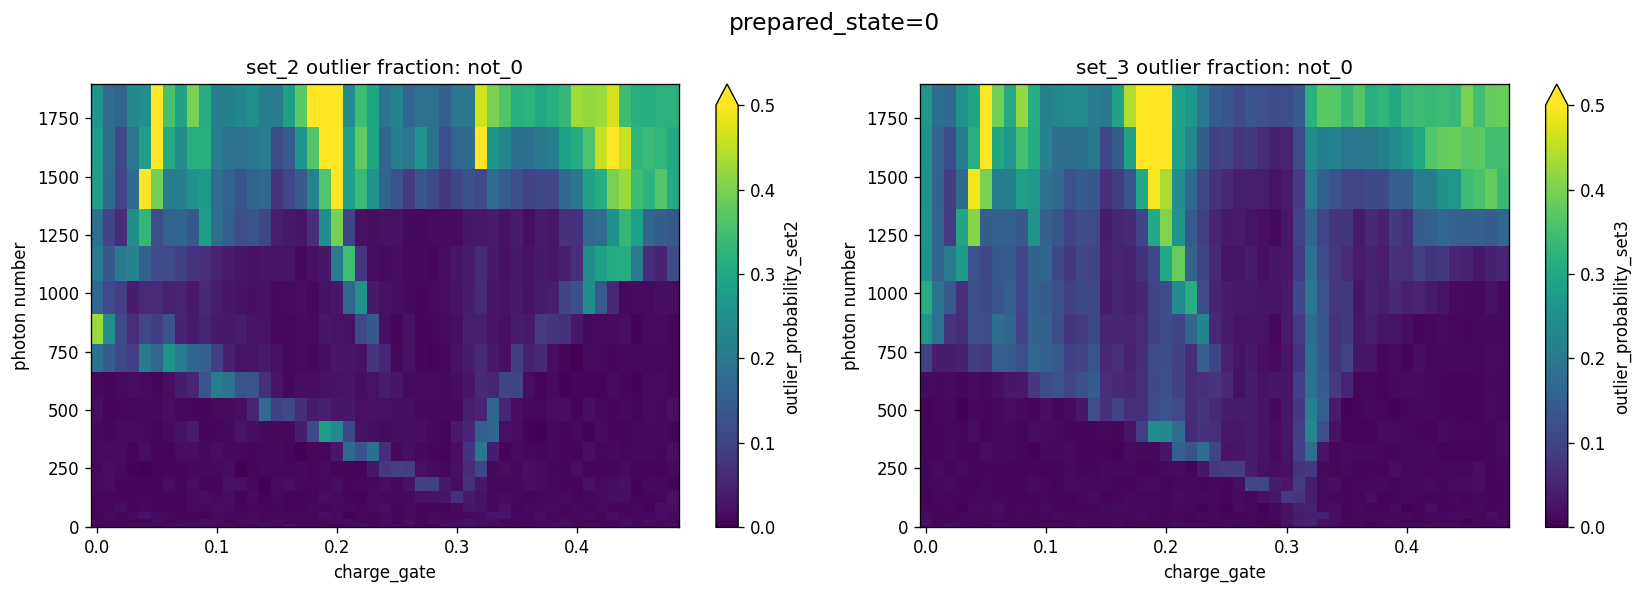

Saved to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\two_step_AR\figures\outlier_fraction_state_1.png


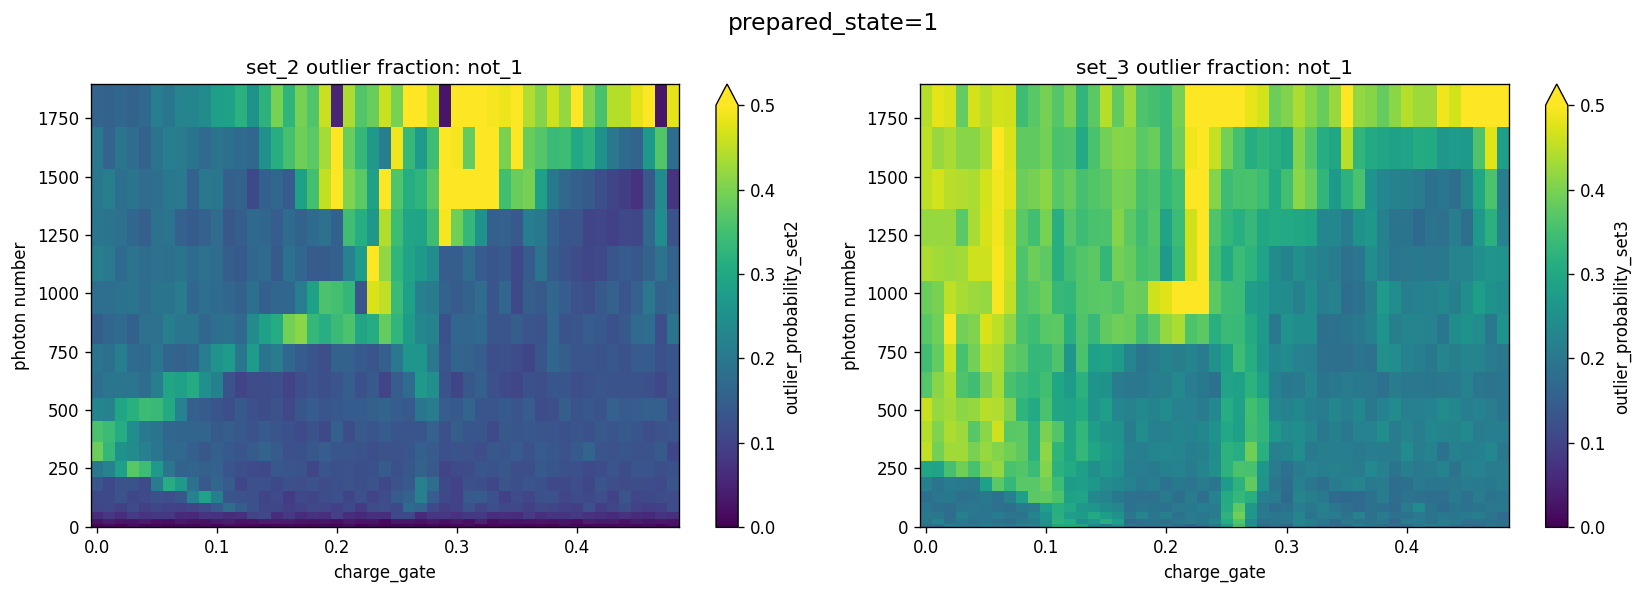

In [80]:
# Plot outlier fraction: one figure per prepared_state, set_2 (left) and set_3 (right)
if photon_convert_factor is not None:
    y_vals = amp_vals**2 * photon_convert_factor
    y_label = 'photon number'
else:
    y_vals = amp_vals
    y_label = 'amp_prefactor'

# Build a temporary result_ds with transformed y-axis for plotting
plot_ds = result_ds.assign_coords(amp_prefactor=y_vals).rename({'amp_prefactor': y_label})

for state in plot_ds.coords['prepared_state'].values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    plot_ds['outlier_probability_set2'].sel(prepared_state=state).plot.pcolormesh(
        ax=axes[0], x='charge_gate', y=y_label,
        cmap='viridis', add_colorbar=True,
        vmin=0, vmax=0.5,
    )
    axes[0].set_title(f"set_2 outlier fraction: not_{int(state)}")

    plot_ds['outlier_probability_set3'].sel(prepared_state=state).plot.pcolormesh(
        ax=axes[1], x='charge_gate', y=y_label,
        cmap='viridis', add_colorbar=True,
        vmin=0, vmax=0.5,
    )
    axes[1].set_title(f"set_3 outlier fraction: not_{int(state)}")

    fig.suptitle(f"prepared_state={int(state)}", fontsize=14)
    fig.tight_layout()
        
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"outlier_fraction_state_{int(state)}.png"), bbox_inches='tight')
    print(f"Saved to {os.path.join(FIGURE_SAVE_PATH, f'outlier_fraction_state_{int(state)}.png')}")
    plt.show()

In [81]:
# Define save path (actual saving happens after pooled analysis)
save_path = os.path.join(os.path.dirname(H5_PATH), "outlier_results.h5")

## Outlier vs amp_prefactor (pooled across charge_gate)
For each `(prepared_state, amp_prefactor)`, pool **all** shots across `charge_gate` (after post-selection), run `SingleStateOutlierAnalyzer`, and plot the outlier probability as a function of `amp_prefactor`.

Saved pooled outlier results to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\two_step_AR\outlier_results.h5
Saved to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\two_step_AR\figures\outlier_vs_amp_prefactor.png


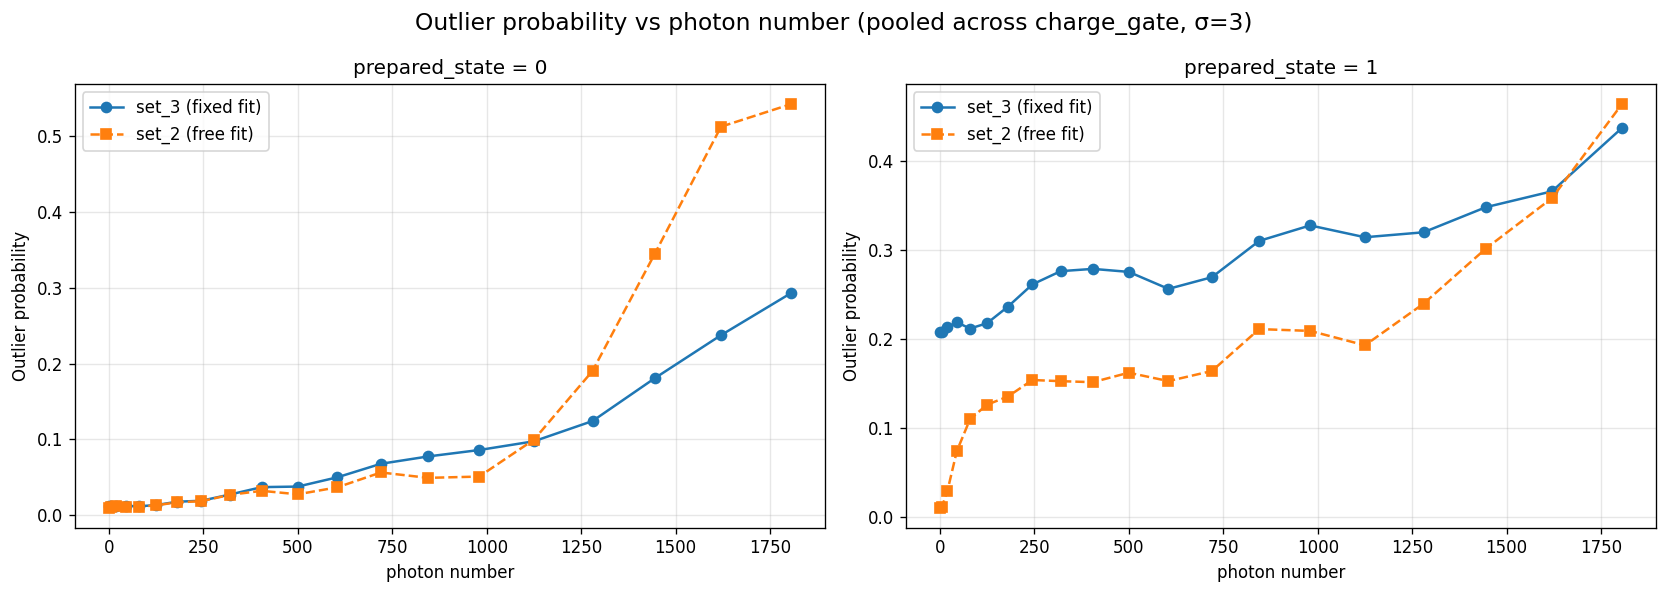

In [82]:
# Pooled outlier analysis: collect all shots across charge_gate for each (prepared_state, amp_prefactor)
outlier_vs_amp = {}  # {state: {'amp': [], 'outlier_prob_set3': [], 'outlier_prob_set2': []}}

for state in prepared_states:
    params_global, _ = outlier_results[int(state)]
    fixed_mean = params_global['fitted_paras']['mean'][0]
    fixed_std = params_global['fitted_paras']['std']

    amp_list = []
    prob_set3 = []
    prob_set2 = []

    for ap in amp_vals:
        # --- set_3 (fixed fit from global parameters) ---
        subset_3 = sq_data[['I1_3', 'Q1_3', 'post_selection_mask']].sel(prepared_state=state, amp_prefactor=ap)
        mask_3 = subset_3['post_selection_mask'].values.ravel()
        I3 = subset_3['I1_3'].values.ravel()[~mask_3]
        Q3 = subset_3['Q1_3'].values.ravel()[~mask_3]

        if len(I3) < 10:
            prob_set3.append(np.nan)
        else:
            ds3 = xr.Dataset(
                {'I': ('shot_idx', I3), 'Q': ('shot_idx', Q3)},
                coords={'shot_idx': np.arange(len(I3))},
            )
            res3, _ = analyzer.analyze(
                ds3, skip_figures=True,
                fixed_mean=fixed_mean, fixed_std=fixed_std,
                outlier_sigma=outlier_sigma,
            )
            prob_set3.append(res3['outlier_probability'])

        # --- set_2 (free fit per amp slice) ---
        subset_2 = sq_data[['I1_2', 'Q1_2', 'post_selection_mask']].sel(prepared_state=state, amp_prefactor=ap)
        mask_2 = subset_2['post_selection_mask'].values.ravel()
        I2 = subset_2['I1_2'].values.ravel()[~mask_2]
        Q2 = subset_2['Q1_2'].values.ravel()[~mask_2]

        if len(I2) < 10:
            prob_set2.append(np.nan)
        else:
            ds2 = xr.Dataset(
                {'I': ('shot_idx', I2), 'Q': ('shot_idx', Q2)},
                coords={'shot_idx': np.arange(len(I2))},
            )
            try:
                res2, _ = analyzer.analyze(
                    ds2, skip_figures=True,
                    outlier_sigma=outlier_sigma,
                )
                prob_set2.append(res2['outlier_probability'])
            except Exception as e:
                print(f"  set_2 fit failed at ap={ap}, state={state}: {e}")
                prob_set2.append(np.nan)

        amp_list.append(ap)

    outlier_vs_amp[int(state)] = {
        'amp': np.array(amp_list),
        'outlier_prob_set3': np.array(prob_set3),
        'outlier_prob_set2': np.array(prob_set2),
    }

# Assemble pooled results into result_ds and re-save
pooled_shape = (len(prepared_states), len(amp_vals))
pooled_prob_set3 = np.full(pooled_shape, np.nan)
pooled_prob_set2 = np.full(pooled_shape, np.nan)
for si, state in enumerate(prepared_states):
    data = outlier_vs_amp[int(state)]
    pooled_prob_set3[si] = data['outlier_prob_set3']
    pooled_prob_set2[si] = data['outlier_prob_set2']

result_ds['pooled_outlier_probability_set3'] = (['prepared_state', 'amp_prefactor'], pooled_prob_set3)
result_ds['pooled_outlier_probability_set2'] = (['prepared_state', 'amp_prefactor'], pooled_prob_set2)

result_ds.to_netcdf(save_path, engine='h5netcdf')
print(f"Saved pooled outlier results to {save_path}")

# --- Plot ---
if photon_convert_factor is not None:
    plot_x = amp_vals**2 * photon_convert_factor
    x_label = 'photon number'
else:
    plot_x = amp_vals
    x_label = 'amp_prefactor'

fig, axes = plt.subplots(1, len(prepared_states), figsize=(7 * len(prepared_states), 5), dpi=120, squeeze=False)
axes = axes.ravel()

for idx, state in enumerate(prepared_states):
    ax = axes[idx]
    data = outlier_vs_amp[int(state)]
    ax.plot(plot_x, data['outlier_prob_set3'], 'o-', label='set_3 (fixed fit)')
    ax.plot(plot_x, data['outlier_prob_set2'], 's--', label='set_2 (free fit)')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Outlier probability')
    ax.set_title(f'prepared_state = {int(state)}')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Outlier probability vs {x_label} (pooled across charge_gate, σ={outlier_sigma})', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "outlier_vs_amp_prefactor.png"), bbox_inches='tight')
print(f"Saved to {os.path.join(FIGURE_SAVE_PATH, 'outlier_vs_amp_prefactor.png')}")
plt.show()